<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/Part2_Experiments_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1 — Gradual Unfreezing on ResNet50

Will be setting up our data loaders for our 3 experiments

1.   Linear Probing
2.   Full Fine-Tuning
3.   Progressive Unfreezing

But the three expriments share the same "beginning"



## 1. Setup and imports

Mounts Drive, imports libraries, fixes random seeds for reproducibility, and confirm GPU usage

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.multiprocessing as mp
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'gpu: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
device: cuda
gpu: NVIDIA A100-SXM4-40GB


## 2. Paths and shared training config


In [2]:
# central config — anything we might tweak lives here
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')
INDEX_DIR = DRIVE_ROOT / 'sample_index'
RESULTS_DIR = DRIVE_ROOT / 'results' / 'exp1_gradual_unfreezing'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# training config shared across A, B, C
IMG_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_EPOCHS = 20
LR = 1e-3              # base lr; backbone lr will be set lower in B and C
WEIGHT_DECAY = 1e-4
PATIENCE = 5           # early stopping on val loss

# imagenet stats — required because the backbone is pretrained on imagenet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f'results dir: {RESULTS_DIR}')

results dir: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp1_gradual_unfreezing


## 3. Copy dataset to local SSD

Drive is too slow as a data source for training. We copy raw images to the runtime's local SSD once per session. The function is idempotent — if the destination already has the expected number of files, it skips. Originals on Drive are never touched.

In [ ]:
# 10 min worth it
import shutil

LOCAL_ROOT = Path('/content/dataset_local')
DRIVE_RAW = DRIVE_ROOT / 'raw'

EXPECTED = {'train': 4654, 'val': 1125, 'test': 1124}

def copy_split(split):
    src = DRIVE_RAW / split / 'images'
    dst = LOCAL_ROOT / split / 'images'
    dst.mkdir(parents=True, exist_ok=True)
    existing = len(list(dst.glob('*.png')))
    if existing == EXPECTED[split]:
        print(f'  {split}: already complete ({existing} images)')
        return
    print(f'  {split}: copying {EXPECTED[split]} images...')
    t0 = time.time()
    shutil.copytree(src, dst, dirs_exist_ok=True)
    n = len(list(dst.glob('*.png')))
    print(f'  {split}: {n} images copied in {time.time()-t0:.0f}s')

print('copying dataset to local SSD...')
for split in ['train', 'val', 'test']:
    copy_split(split)
print('done.')

copying dataset to local SSD...
  train: copying 4654 images...


## 4. Load sample index from EDA

Reads the three JSONs (train/val/test) and the vocab the EDA produced. No re-processing here: the EDA already filtered everything and left the ground truth ready to consume. Also loads the class_to_idx mapping the model will use internally.

In [ ]:
with open(INDEX_DIR / 'samples_train.json') as f:
    samples_train = json.load(f)
with open(INDEX_DIR / 'samples_val.json') as f:
    samples_val = json.load(f)
with open(INDEX_DIR / 'samples_test.json') as f:
    samples_test = json.load(f)
with open(INDEX_DIR / 'class_vocab.json') as f:
    vocab = json.load(f)

CLASS_TO_IDX = vocab['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in vocab['idx_to_class'].items()}
NUM_CLASSES = len(CLASS_TO_IDX)
CLASSES = vocab['keep_classes']

# rewrite paths from drive to local ssd
DRIVE_PREFIX = str(DRIVE_RAW)
LOCAL_PREFIX = str(LOCAL_ROOT)
for split_samples in [samples_train, samples_val, samples_test]:
    for s in split_samples:
        s['img_path'] = s['img_path'].replace(DRIVE_PREFIX, LOCAL_PREFIX)

# sanity check  first sample's path should now point to /content/
print(f'first train sample path: {samples_train[0]["img_path"]}')
print(f'classes: {NUM_CLASSES}  ({CLASSES})')
print(f'train: {len(samples_train):,}  val: {len(samples_val):,}  test: {len(samples_test):,}')

## 5. Class distribution check

Confirm the dataset is balanced. With cap=1000 applied uniformly, every class should have exactly 1000 train samples — meaning we don't need class-weighted loss. We can use plain CrossEntropyLoss.

In [ ]:
# print per-class counts to confirm balance
counts = Counter(s['class_name'] for s in samples_train)
print('train counts per class:')
for cls in sorted(CLASS_TO_IDX, key=lambda c: CLASS_TO_IDX[c]):
    print(f'  {cls:15s} {counts[cls]:>5,d}')
print(f'\ntotal: {sum(counts.values()):,}')
print(f'imbalance ratio (max/min): {max(counts.values()) / min(counts.values()):.2f}x')

## 6. In-memory dataset utilities

Pre-load all crops into RAM as `uint8` tensors (~150KB each). After pre-loading, the DataLoader is just tensor indexing — no PIL, no I/O, no transforms during training. Normalization is applied per-getitem on CPU.

This is the result of significant debugging: DataLoader workers reading from Drive or even local SSD caused silent deadlocks. With everything in RAM and `num_workers=0`, there's nothing to deadlock — and nothing to parallelize either, since indexing a tensor is microseconds.

In [ ]:
# preload crops to ram as uint8 tensors
def preload_to_ram(samples):
    n = len(samples)
    imgs = torch.empty((n, 3, IMG_SIZE, IMG_SIZE), dtype=torch.uint8)
    labels = torch.empty((n,), dtype=torch.long)

    t0 = time.time()
    for i in range(n):
        s = samples[i]
        img = Image.open(s['img_path']).convert('RGB')
        x1, y1, x2, y2 = s['bbox']
        crop = img.crop((x1, y1, x2, y2))
        crop = crop.resize((IMG_SIZE, IMG_SIZE))
        # convert PIL to tensor in HWC uint8, then permute to CHW
        arr = np.asarray(crop)
        imgs[i] = torch.from_numpy(arr).permute(2, 0, 1)
        labels[i] = s['label']
        if (i + 1) % 1000 == 0:
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            print(f'  loaded {i+1:>5,d} / {n:,}  ({rate:.0f}/s)')
    print(f'done: {n:,} samples in {(time.time()-t0):.0f}s')
    return imgs, labels


# in-memory dataset, normalization happens here
class InMemoryDataset(Dataset):
    def __init__(self, imgs, labels):
        self.imgs = imgs
        self.labels = labels
        # imagenet stats scaled to [0,255] range so we can apply to uint8 directly
        self.mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1) * 255
        self.std = torch.tensor(IMAGENET_STD).view(3, 1, 1) * 255

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        x = self.imgs[i].float()
        x = (x - self.mean) / self.std
        return x, self.labels[i]


print('preload utilities defined')

## 7. Pre-load all splits to RAM

Pre-load train, val, and test. Cached to disk so future sessions in the same VM skip the preload. Total memory: ~2.5 GB for all three splits (16.5k samples × 150KB).

In [ ]:
# 3 min
CACHE_DIR = Path('/content/dataset_local')

def preload_or_load(samples, name):
    path = CACHE_DIR / f'preloaded_{name}.pt'
    if path.exists():
        print(f'{name}: loading from cache...')
        t0 = time.time()
        cache = torch.load(path)
        print(f'{name}: loaded {len(cache["imgs"]):,} samples in {time.time()-t0:.0f}s')
        return cache['imgs'], cache['labels']
    print(f'{name}: pre-loading {len(samples):,} samples...')
    imgs, labels = preload_to_ram(samples)
    torch.save({'imgs': imgs, 'labels': labels}, path)
    print(f'{name}: cached to {path}')
    return imgs, labels

train_imgs, train_labels = preload_or_load(samples_train, 'train')
val_imgs, val_labels = preload_or_load(samples_val, 'val')
test_imgs, test_labels = preload_or_load(samples_test, 'test')

train_ds = InMemoryDataset(train_imgs, train_labels)
val_ds = InMemoryDataset(val_imgs, val_labels)
test_ds = InMemoryDataset(test_imgs, test_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'\nloaders ready:')
print(f'  train: {len(train_loader)} batches')
print(f'  val:   {len(val_loader)} batches')
print(f'  test:  {len(test_loader)} batches')

## 7.1  Visual sanity check

Confirm the crops look right after resize and are paired with sensible labels. We undo the normalization for display only.

In [ ]:
xb, yb = next(iter(train_loader))
print(f'batch shape: {xb.shape}, labels shape: {yb.shape}')
print(f'pixel range after normalize: [{xb.min():.2f}, {xb.max():.2f}]')

mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
display = (xb[:8] * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.flat, display, yb[:8]):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(IDX_TO_CLASS[lbl.item()], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Shared helpers — Model, freeze utilities, train/eval loops

Antes de las variantes, definimos lo que las tres comparten: cómo construir el ResNet50, helpers para congelar/descongelar capas, y los loops de train/eval. Cada variante después usa estos helpers con su propio setup.

In [ ]:
import torchvision.models as models
from torch.amp import autocast, GradScaler

# build resnet50 with imagenet pretrained weights
# v2 weights are the most recent and best from torchvision
def build_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    # replace the final layer (originally 1000 classes for imagenet) with our 11
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

# turn off gradients for every parameter — the model becomes a fixed feature extractor
def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

# turn gradients back on for any parameter whose name starts with one of the prefixes
# example: unfreeze(model, ['layer4']) re-enables training for the last resnet block
def unfreeze(model, prefixes):
    for n, p in model.named_parameters():
        if any(n.startswith(pre) for pre in prefixes):
            p.requires_grad = True

# quick sanity check on how many params will actually receive gradient updates
def count_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

# one full pass over the training set
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for xb, yb in loader:
        # move batch to gpu — non_blocking helps overlap data transfer with compute
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        # set_to_none is faster than zeroing — frees the gradient memory
        optimizer.zero_grad(set_to_none=True)
        # autocast runs ops in float16 where safe, float32 where precision matters
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        # scaler prevents float16 underflow during backprop
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # track running totals so we can report epoch averages
        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n

# one full pass over the validation set, no gradients
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    # per class tracking so we can see whether sign and other rare classes are learning
    per_class_correct = torch.zeros(NUM_CLASSES)
    per_class_total = torch.zeros(NUM_CLASSES)
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with autocast(device_type='cuda', dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        preds = logits.argmax(1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total_n += xb.size(0)
        # count correct predictions per class for the per-class accuracy table
        for c in range(NUM_CLASSES):
            mask = (yb == c)
            per_class_total[c] += mask.sum().item()
            per_class_correct[c] += (preds[mask] == c).sum().item()
    # clamp avoids divide-by-zero if a class has no samples in val (shouldn't happen but safe)
    per_class_acc = (per_class_correct / per_class_total.clamp(min=1)).tolist()
    return total_loss / total_n, total_correct / total_n, per_class_acc

print('helpers defined')

## 9. Variant A — Linear Probing

Linear probing: backbone fully frozen, only the new `fc` head trains (~22k of 23.5M params). The backbone stays as a fixed feature extractor — ImageNet's edge/texture/shape features feed directly into a linear classifier over our 11 classes. This sets the performance floor: how well we do without modifying any pretrained weights.

### 9.1 Setup

Build the model, freeze all parameters, re enable gradients only on `fc`. AdamW optimizer with weight decay "Eoin lecture". ReduceLROnPlateau halves the LR if val loss stalls.

In [ ]:
VARIANT = 'A'
VARIANT_DIR = RESULTS_DIR / f'exp1_{VARIANT}'
VARIANT_DIR.mkdir(parents=True, exist_ok=True)

# build fresh model and apply linear probing setup
model = build_model(NUM_CLASSES).to(device)
freeze_all(model)
for p in model.fc.parameters():
    p.requires_grad = True

# optimizer only sees the head's params
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)

# halve lr if val loss plateaus for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# plain cross entropy — dataset is balanced (1000 per class), no weights needed
criterion = nn.CrossEntropyLoss()

trainable, total = count_trainable(model)
print(f'variant A: {trainable:,} / {total:,} trainable params')
print(f'output dir: {VARIANT_DIR}')

variant A: 22,539 / 23,530,571 trainable params
output dir: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp1_gradual_unfreezing/exp1_A


### 9.2 Train Variant A

Training loop with early stopping (stops if val loss doesn't improve for `PATIENCE` epochs) and best-checkpoint saving (overwrites `best.pt` whenever val loss reaches a new minimum). The `history.json` saved at the end has every per-epoch metric for the comparison plots later.

In [ ]:
# 5 min
ckpt_path = VARIANT_DIR / 'best.pt'
scaler = GradScaler()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
           'lr': [], 'per_class_val_acc': []}

best_val_loss = float('inf')
epochs_no_improve = 0
t0 = time.time()

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc, per_class_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    history['per_class_val_acc'].append(per_class_acc)

    elapsed = (time.time() - t0) / 60
    print(f'epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {val_loss:.4f} acc {val_acc:.4f} | '
          f'lr {current_lr:.2e} | {elapsed:.1f} min')

    # save checkpoint at every new best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({'model_state': model.state_dict(),
                    'epoch': epoch, 'val_loss': val_loss, 'val_acc': val_acc},
                   ckpt_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'early stopping at epoch {epoch}')
            break

history['total_time_min'] = (time.time() - t0) / 60
with open(VARIANT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\ntotal time: {history["total_time_min"]:.1f} min')
print(f'saved checkpoint: {ckpt_path}')

epoch  0 | train loss 1.1936 acc 0.7342 | val loss 0.6664 acc 0.8545 | lr 1.00e-03 | 0.3 min
epoch  1 | train loss 0.5420 acc 0.8758 | val loss 0.4546 acc 0.8916 | lr 1.00e-03 | 0.5 min
epoch  2 | train loss 0.3932 acc 0.9088 | val loss 0.3701 acc 0.9153 | lr 1.00e-03 | 0.8 min
epoch  3 | train loss 0.3161 acc 0.9268 | val loss 0.3115 acc 0.9255 | lr 1.00e-03 | 1.1 min
epoch  4 | train loss 0.2654 acc 0.9404 | val loss 0.2760 acc 0.9309 | lr 1.00e-03 | 1.4 min
epoch  5 | train loss 0.2338 acc 0.9477 | val loss 0.2497 acc 0.9393 | lr 1.00e-03 | 1.6 min
epoch  6 | train loss 0.2047 acc 0.9556 | val loss 0.2296 acc 0.9447 | lr 1.00e-03 | 1.9 min
epoch  7 | train loss 0.1821 acc 0.9596 | val loss 0.2167 acc 0.9458 | lr 1.00e-03 | 2.2 min
epoch  8 | train loss 0.1621 acc 0.9655 | val loss 0.2012 acc 0.9498 | lr 1.00e-03 | 2.5 min
epoch  9 | train loss 0.1494 acc 0.9688 | val loss 0.1946 acc 0.9509 | lr 1.00e-03 | 2.7 min
epoch 10 | train loss 0.1377 acc 0.9722 | val loss 0.1795 acc 0.9553 |

### 9.3 Plos Loss and Accuracy

Visualize loss and accuracy across epochs to see the training dynamics — does loss decrease monotonically, does val track train (no overfitting), when does the LR scheduler kick in.

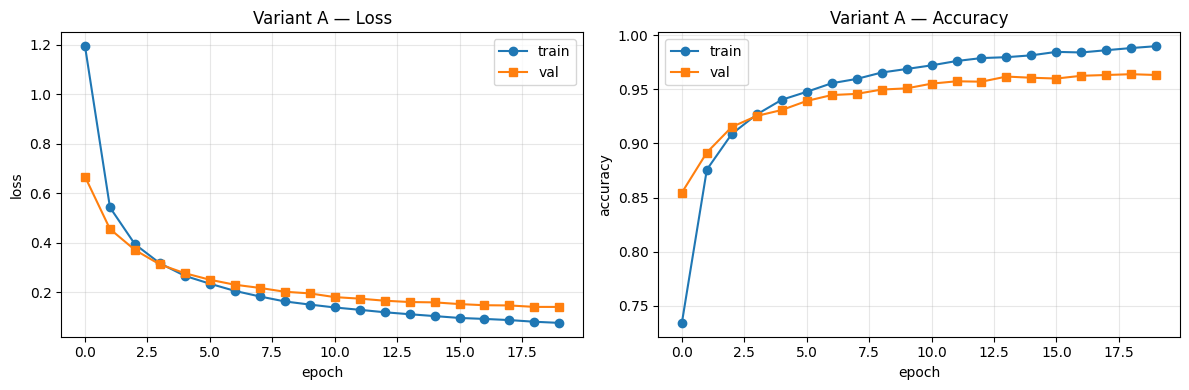

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_run = range(len(history['train_loss']))
axes[0].plot(epochs_run, history['train_loss'], label='train', marker='o')
axes[0].plot(epochs_run, history['val_loss'], label='val', marker='s')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Variant A — Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_run, history['train_acc'], label='train', marker='o')
axes[1].plot(epochs_run, history['val_acc'], label='val', marker='s')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('Variant A — Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(VARIANT_DIR / 'curves.png', dpi=120)
plt.show()

### 9.4 Per-class validation accuracy

Even with a balanced dataset, some classes are intrinsically harder. This breakdown was supposed to show where the model "struggles" for the report and for understanding what features the frozen backbone is capturing well or poorly.

In [ ]:
# per-class accuracy at the best (saved) epoch
best_epoch = int(np.argmin(history['val_loss']))
best_per_class = history['per_class_val_acc'][best_epoch]

print(f'per-class val accuracy at best epoch ({best_epoch}):\n')
for cls, idx in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1]):
    bar = '█' * int(best_per_class[idx] * 30)
    print(f'  {cls:15s} {best_per_class[idx]:.3f}  {bar}')

per-class val accuracy at best epoch (19):

  box             0.988  █████████████████████████████
  ceiling         0.964  ████████████████████████████
  floor           0.988  █████████████████████████████
  floor_decal     0.984  █████████████████████████████
  lamp            0.964  ████████████████████████████
  pallet          0.976  █████████████████████████████
  pillar          0.956  ████████████████████████████
  rack            0.956  ████████████████████████████
  sign            0.992  █████████████████████████████
  wall            0.892  ██████████████████████████
  wire            0.936  ████████████████████████████


In [ ]:
# was suspicious about the performance so we discarted data leakage.
train_imgs_set = {s['img_path'] for s in samples_train}
val_imgs_set = {s['img_path'] for s in samples_val}
overlap = train_imgs_set & val_imgs_set
print(f'images in both train and val: {len(overlap)}')

images in both train and val: 0


### 9.5 Final test evaluation

After training is complete, we evaluate the saved best checkpoint on the held out test set.

This is the honest final number for Variant A — the model never saw test data during training nor during early-stopping decisions.

This is what gets reported and compared against Variants B and C.

In [ ]:
# load the best checkpoint (the one saved at lowest val loss)
ckpt = torch.load(VARIANT_DIR / 'best.pt')
model.load_state_dict(ckpt['model_state'])
print(f'loaded checkpoint from epoch {ckpt["epoch"]} (val_loss={ckpt["val_loss"]:.4f})')

# evaluate on test
test_loss, test_acc, test_per_class = evaluate(model, test_loader, criterion)

print(f'\nTest results — Variant A (Linear Probing)')
print(f'  test loss: {test_loss:.4f}')
print(f'  test acc:  {test_acc:.4f}')

print(f'\nper-class test accuracy:')
for cls, idx in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1]):
    bar = '█' * int(test_per_class[idx] * 30)
    print(f'  {cls:15s} {test_per_class[idx]:.3f}  {bar}')

# save test results to history.json so the comparison cell later can pick them up
with open(VARIANT_DIR / 'history.json') as f:
    history = json.load(f)
history['test_loss'] = test_loss
history['test_acc'] = test_acc
history['test_per_class_acc'] = test_per_class
with open(VARIANT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nupdated {VARIANT_DIR / "history.json"} with test results')

loaded checkpoint from epoch 19 (val_loss=0.1398)

Test results — Variant A (Linear Probing)
  test loss: 0.1586
  test acc:  0.9527

per-class test accuracy:
  box             0.952  ████████████████████████████
  ceiling         0.960  ████████████████████████████
  floor           0.976  █████████████████████████████
  floor_decal     0.988  █████████████████████████████
  lamp            0.976  █████████████████████████████
  pallet          0.972  █████████████████████████████
  pillar          0.896  ██████████████████████████
  rack            0.972  █████████████████████████████
  sign            1.000  ██████████████████████████████
  wall            0.848  █████████████████████████
  wire            0.940  ████████████████████████████

updated /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp1_gradual_unfreezing/exp1_A/history.json with test results


## 10. Variant B — Full Fine-Tuning

Full fine-tuning unfreezes the entire network: backbone and head train together, all 23.5M parameters receive gradient updates. Unlike Variant A where ImageNet features stayed fixed, here the pretrained weights adapt to the warehouse dataset.

The learning rate drops to 1e-4 (10x lower than A). With 1e-3 the updates would be too aggressive on the already-trained backbone weights and would erase the useful ImageNet features — that is the standard reason linear probing uses a high LR while full fine-tuning uses a low one.

No differential LR between backbone and head on purpose: that effect is what Experiment 3 investigates, keeping it out of here preserves the separation between experiments.

### 10.1 Setup

Same `build_model` as A, but nothing is frozen. The optimizer sees every parameter in the model. Scheduler and criterion are identical to A so that the only real variable across the three variants is the unfreezing strategy.

In [ ]:
VARIANT = 'B'
VARIANT_DIR = RESULTS_DIR / f'exp1_{VARIANT}'
VARIANT_DIR.mkdir(parents=True, exist_ok=True)

# fresh model, no freezing - every param trains
model = build_model(NUM_CLASSES).to(device)

# 10x lower than variant A - high lr would overwrite the pretrained backbone
LR_FT = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FT, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss()

trainable, total = count_trainable(model)
print(f'variant B: {trainable:,} / {total:,} trainable params')
print(f'output dir: {VARIANT_DIR}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


variant B: 23,530,571 / 23,530,571 trainable params
output dir: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp1_gradual_unfreezing/exp1_B


### 10.2 Train Variant B

Loop identical to Variant A: early stopping after `PATIENCE` epochs without improvement, best checkpoint saved to `best.pt`, full per-epoch history saved to `history.json`. The only thing that differs is what trains underneath, which means each epoch takes roughly twice as long because backprop now flows through the entire network.

In [ ]:
# 10-12 min for 20 epochs on L4, A100 made it in 1min
ckpt_path = VARIANT_DIR / 'best.pt'
scaler = GradScaler()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
           'lr': [], 'per_class_val_acc': []}

best_val_loss = float('inf')
epochs_no_improve = 0
t0 = time.time()

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc, per_class_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    history['per_class_val_acc'].append(per_class_acc)

    elapsed = (time.time() - t0) / 60
    print(f'epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {val_loss:.4f} acc {val_acc:.4f} | '
          f'lr {current_lr:.2e} | {elapsed:.1f} min')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({'model_state': model.state_dict(),
                    'epoch': epoch, 'val_loss': val_loss, 'val_acc': val_acc},
                   ckpt_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'early stopping at epoch {epoch}')
            break

history['total_time_min'] = (time.time() - t0) / 60
with open(VARIANT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\ntotal time: {history["total_time_min"]:.1f} min')
print(f'saved checkpoint: {ckpt_path}')

epoch  0 | train loss 0.7324 acc 0.8323 | val loss 0.0899 acc 0.9738 | lr 1.00e-04 | 0.2 min
epoch  1 | train loss 0.0450 acc 0.9884 | val loss 0.0508 acc 0.9858 | lr 1.00e-04 | 0.5 min
epoch  2 | train loss 0.0114 acc 0.9981 | val loss 0.0526 acc 0.9844 | lr 1.00e-04 | 0.7 min
epoch  3 | train loss 0.0051 acc 0.9994 | val loss 0.0398 acc 0.9869 | lr 1.00e-04 | 0.9 min
epoch  4 | train loss 0.0055 acc 0.9989 | val loss 0.0476 acc 0.9865 | lr 1.00e-04 | 1.1 min
epoch  5 | train loss 0.0028 acc 0.9995 | val loss 0.0411 acc 0.9902 | lr 1.00e-04 | 1.3 min
epoch  6 | train loss 0.0054 acc 0.9988 | val loss 0.0495 acc 0.9858 | lr 5.00e-05 | 1.6 min
epoch  7 | train loss 0.0038 acc 0.9990 | val loss 0.0416 acc 0.9876 | lr 5.00e-05 | 1.8 min
epoch  8 | train loss 0.0014 acc 0.9998 | val loss 0.0420 acc 0.9887 | lr 5.00e-05 | 2.0 min
early stopping at epoch 8

total time: 2.0 min
saved checkpoint: /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp1_gradual_unfreezing/exp1_B/best.pt


### 10.3 Plots — Loss and Accuracy

Same curves as Variant A: train vs val for both loss and accuracy. The thing to watch here is whether val starts pulling away from train (sign of overfitting), since with 23.5M trainable params the model now has enough capacity to memorize 11k crops.

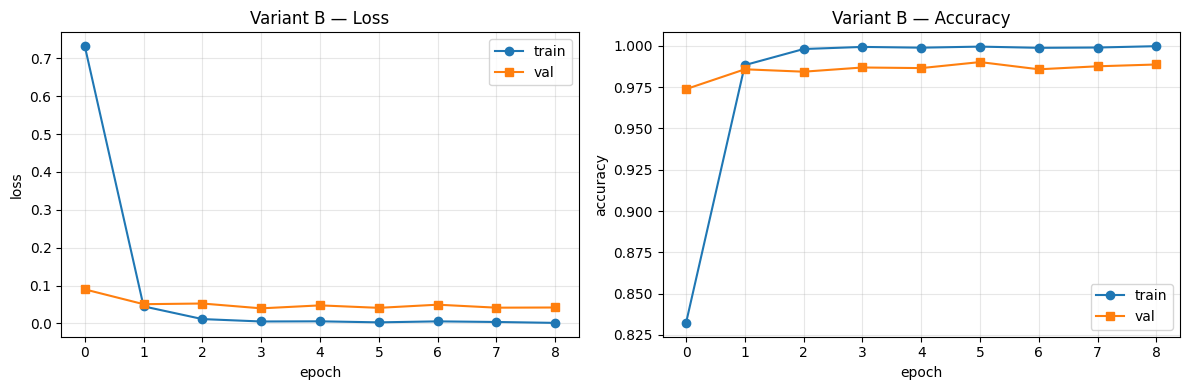

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_run = range(len(history['train_loss']))
axes[0].plot(epochs_run, history['train_loss'], label='train', marker='o')
axes[0].plot(epochs_run, history['val_loss'], label='val', marker='s')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Variant B — Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_run, history['train_acc'], label='train', marker='o')
axes[1].plot(epochs_run, history['val_acc'], label='val', marker='s')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('Variant B — Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(VARIANT_DIR / 'curves.png', dpi=120)
plt.show()

### 10.4 Per-class validation accuracy

Same per-class breakdown as Variant A. The hypothesis is that classes where A struggled (wall 84.8%, pillar 89.6%) should benefit most, because the backbone can now learn dataset-specific features instead of relying solely on ImageNet's.

In [ ]:
best_epoch = int(np.argmin(history['val_loss']))
best_per_class = history['per_class_val_acc'][best_epoch]

print(f'per-class val accuracy at best epoch ({best_epoch}):\n')
for cls, idx in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1]):
    bar = '█' * int(best_per_class[idx] * 30)
    print(f'  {cls:15s} {best_per_class[idx]:.3f}  {bar}')

per-class val accuracy at best epoch (3):

  box             1.000  ██████████████████████████████
  ceiling         0.992  █████████████████████████████
  floor           0.992  █████████████████████████████
  floor_decal     1.000  ██████████████████████████████
  lamp            0.984  █████████████████████████████
  pallet          1.000  ██████████████████████████████
  pillar          0.972  █████████████████████████████
  rack            0.988  █████████████████████████████
  sign            1.000  ██████████████████████████████
  wall            0.948  ████████████████████████████
  wire            0.980  █████████████████████████████


### 10.5 Final test evaluation

Load the best checkpoint and evaluate on test. Same protocol as A: the model never saw test data during training nor for early-stopping decisions. This number is what gets compared against A and C in the final comparison section.

In [ ]:
ckpt = torch.load(VARIANT_DIR / 'best.pt')
model.load_state_dict(ckpt['model_state'])
print(f'loaded checkpoint from epoch {ckpt["epoch"]} (val_loss={ckpt["val_loss"]:.4f})')

test_loss, test_acc, test_per_class = evaluate(model, test_loader, criterion)

print(f'\nTest results — Variant B (Full Fine-Tuning)')
print(f'  test loss: {test_loss:.4f}')
print(f'  test acc:  {test_acc:.4f}')

print(f'\nper-class test accuracy:')
for cls, idx in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1]):
    bar = '█' * int(test_per_class[idx] * 30)
    print(f'  {cls:15s} {test_per_class[idx]:.3f}  {bar}')

# append test results to history.json for the comparison cell later
with open(VARIANT_DIR / 'history.json') as f:
    history = json.load(f)
history['test_loss'] = test_loss
history['test_acc'] = test_acc
history['test_per_class_acc'] = test_per_class
with open(VARIANT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nupdated {VARIANT_DIR / "history.json"} with test results')

loaded checkpoint from epoch 3 (val_loss=0.0398)

Test results — Variant B (Full Fine-Tuning)
  test loss: 0.0518
  test acc:  0.9884

per-class test accuracy:
  box             0.996  █████████████████████████████
  ceiling         1.000  ██████████████████████████████
  floor           0.988  █████████████████████████████
  floor_decal     1.000  ██████████████████████████████
  lamp            1.000  ██████████████████████████████
  pallet          1.000  ██████████████████████████████
  pillar          0.984  █████████████████████████████
  rack            0.984  █████████████████████████████
  sign            1.000  ██████████████████████████████
  wall            0.932  ███████████████████████████
  wire            0.988  █████████████████████████████

updated /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/exp1_gradual_unfreezing/exp1_B/history.json with test results
